# Veri Bilimi Eğitimi


## Zaman Serisi Analizi

Amaç:
  1. Veri setindeki tarih bilgisini kullanarak zaman bazlı analiz yapmak

Adımlar:
  1. Veri setini yüklemek
  2. Sipariş tarihini datetime tipine dönüştür
  3. Tarih sütunundan zaman özellikleri türet
  4. Aylara göre sipariş yoğunluğunu incele
  5. Ayın ilk yarısı ve ikinci yarısında ki harcama farkını incele
  6. Hafta içi ve hafta sonu sipariş davranışlarını karşılaştırma
  7. İki haftalık dönemlerde ortalama sipariş tutarı inceleme

  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. veri setinin yüklenmesi
df = pd.read_csv("e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [ ]:
# 2. sipariş tarihini datetime tipine dönüştür
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_tarihi"].dtype

dtype('<M8[ns]')

In [ ]:
# 3. tarih sütunundan zaman özellikleri üretelim
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()
df["hafta_numarasi"] = df["siparis_tarihi"].dt.isocalendar().week.astype(int)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday,2
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday,32
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday,34
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday,32
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday,31


In [ ]:
# 4. aylara göre sipariş yoğunluk
aylik_yogunluk = (
    df.groupby("siparis_ayi")
    .agg(
        siparis_sayisi = ("siparis_id", "count"),
        benzersiz_musteri_sayisi = ("musteri_id", "nunique")
    )
    .reset_index()
    .sort_values("siparis_ayi")
)
aylik_yogunluk

,siparis_ayi,siparis_sayisi,benzersiz_musteri_sayisi
0,1,97,89
1,2,84,75
2,3,94,81
3,4,111,94
4,5,102,94
5,6,85,77
6,7,79,71
7,8,80,71
8,9,91,83
9,10,89,80


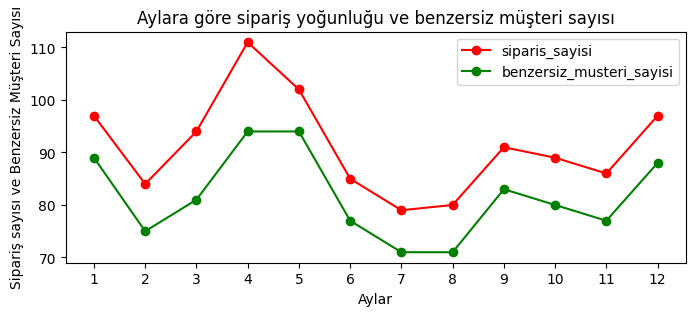

In [ ]:
plt.figure(figsize = (8,3))
plt.plot(aylik_yogunluk["siparis_ayi"], aylik_yogunluk["siparis_sayisi"], marker = "o", color = "red", label = "siparis_sayisi")
plt.plot(aylik_yogunluk["siparis_ayi"], aylik_yogunluk["benzersiz_musteri_sayisi"], marker = "o", color = "green", label = "benzersiz_musteri_sayisi")
plt.title("Aylara göre sipariş yoğunluğu ve benzersiz müşteri sayısı")
plt.ylabel("Sipariş sayısı ve Benzersiz Müşteri Sayısı")
plt.xlabel("Aylar")
plt.xticks(aylik_yogunluk["siparis_ayi"])
plt.legend()
plt.show()

In [ ]:
# 5. ayın ilk yarısı ve ikinci yarısında ki harcama farkını inceleme
# ayın ilk yarısı ve ikinci yarısı bulma
df["ay_donemi"] = df["siparis_gunu"].apply(
    lambda x: "Ayın ilk yarısı" if x <= 15 else "Ayın ikinci yarısı"
)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,5.0,Hayır,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,5.0,Hayır,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,5.0,Hayır,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı


In [ ]:
ay_donemi_analizi = (
    df.groupby("ay_donemi")
    .agg(
        toplam_tutar = ("toplam_tutar", "sum")
    )
    .round(1)
    .reset_index()
)
ay_donemi_analizi

,ay_donemi,toplam_tutar
0,Ayın ikinci yarısı,413476.0
1,Ayın ilk yarısı,439922.1


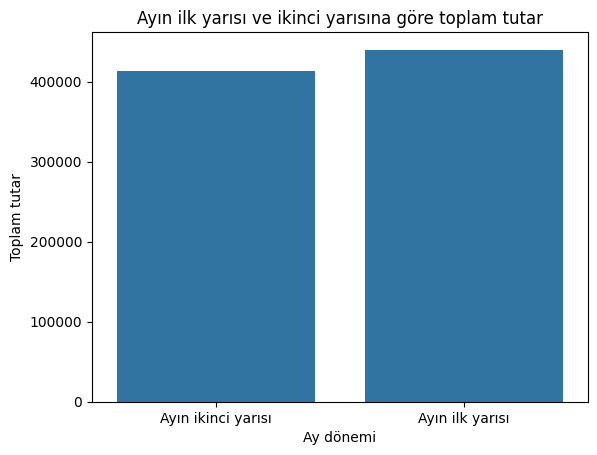

In [ ]:
plt.figure()
sns.barplot(data = ay_donemi_analizi, x = "ay_donemi", y= "toplam_tutar")
plt.title("Ayın ilk yarısı ve ikinci yarısına göre toplam tutar")
plt.xlabel("Ay dönemi")
plt.ylabel("Toplam tutar")
plt.show()

In [ ]:
# 6. hafta içi ve hafta sonu sipariş davranışını karşılaştırma
df["hafta_tipi"] = df["siparis_tarihi"].dt.dayofweek.apply(
    lambda x: "hafta sonu" if x >=5 else "hafta içi"
)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi,hafta_tipi
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,Hayır,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı,hafta sonu
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,Hayır,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı,hafta sonu
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,Hayır,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı,hafta içi
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,Hayır,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı,hafta sonu
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,Hayır,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı,hafta içi


In [ ]:
hafta_tipi_analizi = (
    df.groupby("hafta_tipi")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean"),
    )
    .round(1)
    .reset_index()
)
hafta_tipi_analizi

,hafta_tipi,ortalama_siparis_tutari
0,hafta içi,784.4
1,hafta sonu,767.1


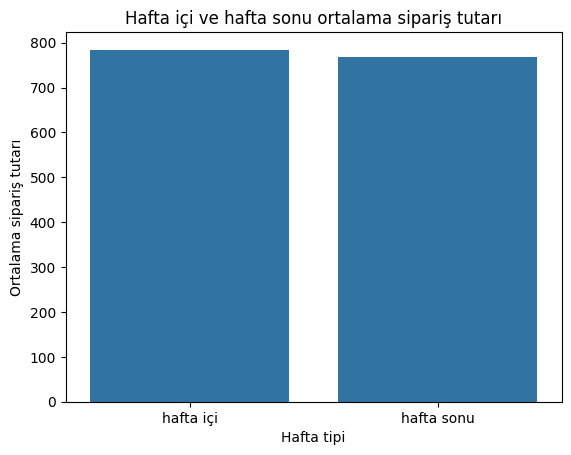

In [ ]:
plt.figure()
sns.barplot(data = hafta_tipi_analizi, x = "hafta_tipi", y = "ortalama_siparis_tutari")
plt.title("Hafta içi ve hafta sonu ortalama sipariş tutarı")
plt.xlabel("Hafta tipi")
plt.ylabel("Ortalama sipariş tutarı")
plt.show()

In [ ]:
# 7. iki haftalık dönemelerde ortalama sipariş tutarı
df["iki_haftalik_donem"] = ((df["hafta_numarasi"] - 1)//2) + 1
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,...,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu,hafta_numarasi,ay_donemi,hafta_tipi,iki_haftalik_donem
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,...,0.220,443.68,2024,1,13,Saturday,2,Ayın ilk yarısı,hafta sonu,1
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,...,0.250,1023.80,2024,8,10,Saturday,32,Ayın ilk yarısı,hafta sonu,16
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,...,0.280,2439.03,2024,8,19,Monday,34,Ayın ikinci yarısı,hafta içi,17
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,...,0.220,893.94,2025,8,9,Saturday,32,Ayın ilk yarısı,hafta sonu,16
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,...,0.283,1291.26,2024,7,30,Tuesday,31,Ayın ikinci yarısı,hafta içi,16


In [ ]:
iki_haftalik_analiz = (
    df.groupby("iki_haftalik_donem")
    .agg(
        ortalama_siparis_tutari = ("toplam_tutar", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("iki_haftalik_donem")
)
iki_haftalik_analiz

,iki_haftalik_donem,ortalama_siparis_tutari
0,1,744.65
1,2,667.21
2,3,895.91
3,4,822.83
4,5,679.51
5,6,751.62
6,7,773.34
7,8,603.19
8,9,606.74
9,10,876.16


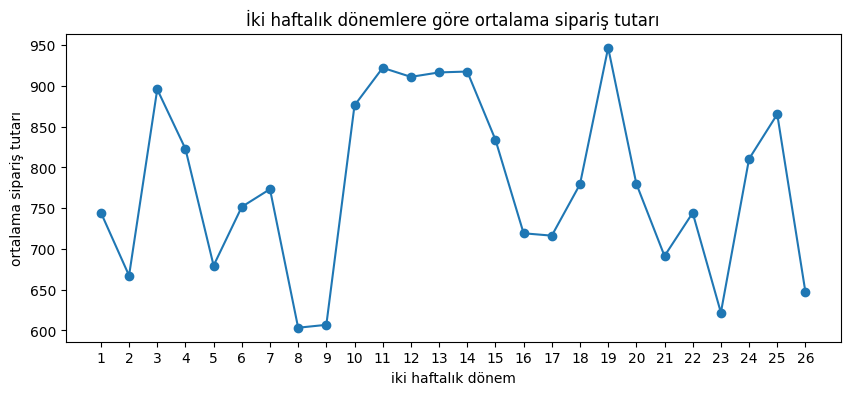

In [ ]:
plt.figure(figsize = (10,4))
plt.plot(iki_haftalik_analiz["iki_haftalik_donem"], iki_haftalik_analiz["ortalama_siparis_tutari"], marker = "o")
plt.title("İki haftalık dönemlere göre ortalama sipariş tutarı")
plt.xlabel("iki haftalık dönem")
plt.xticks(iki_haftalik_analiz["iki_haftalik_donem"])
plt.ylabel("ortalama sipariş tutarı")
plt.show()